# Slow farmer Kolmogorov equations for $N_w$ and $N_g$

In [31]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [32]:
print("Last run: " + time.ctime())

Last run: Wed Feb 19 16:10:27 2025


In [33]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [34]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [35]:
R = 0.00888
K = 0.00772

## setting functions

In [36]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<=t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [37]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [38]:
def qFlatten(q):
    """accepts matrix of shape (A+1, N+1)
    reshape into matrix of shape (A+1)*(N+1)
    """

    dim = q.shape[0]*q.shape[1]

    return np.reshape(q, (dim), "f")

def qExpand(q, N, A):
    """accepts q vector of shape (A+1)*(N+1)
    reshape into matrix (A+1, N+1)
    needs N and A passed to it
    """

    return np.reshape(q, (A+1, N+1), "f")

## Import data

In [39]:
with open("slow_sol_100.dat", "rb") as f:
    sol_100 = pickle.load(f)

## plot evolution of q

Text(0, 0.5, '$q_{x,y}$')

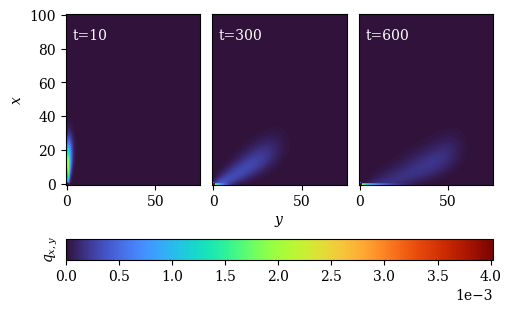

In [40]:
f, axs = plt.subplots(nrows=1, ncols=3, figsize=(5, 3), layout="constrained")

axs = np.reshape(axs, 3)

n=75

data1 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 10)], n, 100)

data2 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 300)], n, 100)

data3 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 600)], n, 100)

#max q
#to use the same color scale in each image
vm = np.max([
    np.max(data1[1:]),
    np.max(data2[1:]),
    np.max(data3[1:])])

for i in range(0,3):
    ptr = axs[i].imshow([data1, data2, data3][i],
                           origin="lower",
                           aspect="auto",
                           cmap="turbo",
                           vmin=0, vmax=vm)

    #axs[i].set_xticks([0, 10, 20, 30, 40])
    axs[i].annotate("t={0}".format([10, 300, 600][i]), (0.05, 0.85),
                    xycoords="axes fraction", color="white")

axs[1].set_xlabel("$y$")
axs[0].set_ylabel("$x$")
axs[1].set_yticks([])
axs[2].set_yticks([])

cb = plt.colorbar(ptr, ax=axs, location="bottom")
cb.formatter.set_powerlimits((-1, 5))
cb.ax.set_ylabel("$q_{x,y}$")

#plt.savefig("q_evolution.pdf")

## Plot example contour of q

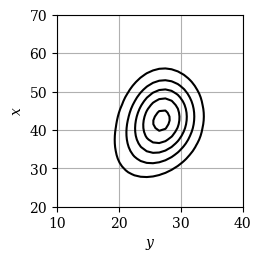

In [41]:
f, ax = plt.subplots(figsize=(2.5, 2.5), layout="constrained")

n=50

data1 = qExpand(sol_100[str(n)]["y"][
                   :,timeToIndex(
                       sol_100[str(n)]["t"], 200)], n, 100)

ptr = ax.contour(np.abs(data1), origin="lower", colors="#000000", levels=5)

ax.axis([10, 40, 20, 70])

ax.set_xticks([10, 20, 30, 40])
ax.set_xlabel("$y$")
ax.set_ylabel("$x$")
ax.annotate("t=200", (0.05, 0.85), xycoords="axes fraction", color="white")

ax.grid(True)

#plt.savefig("q_evolution.pdf")

## plot evolution of $\sum_{x}q_{x,y}$
i.e. the PMF of $N_w$, summed across all values of $N_g$

In [42]:
def nwpmf(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    unflatten qxy into (A+1)x(N+1) array and sum over the Ng axis"""
    return np.sum(qExpand(qxy, N, A), axis=0)

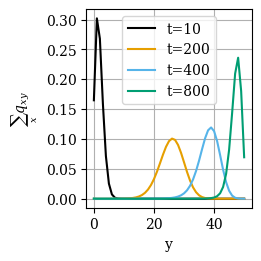

In [43]:
f, ax = plt.subplots(layout="constrained", figsize=(2.5, 2.5))

ax.set_prop_cycle(wong_cycle)

for i in [10, 200, 400, 800]:
    ax.plot(nwpmf(sol_100["50"]["y"][:,timeToIndex(sol_100["50"]["t"], i)], 50, 100), label="t={0}".format(i))

ax.grid(True)
ax.set_xlabel("y")
ax.set_ylabel("$\sum_{x}q_{xy}$")
ax.legend(loc="upper center")

#plt.savefig("q_nw_evolution.pdf")

## F_slow plots

In [44]:
def expectedNw(qxy, N, A):
    """accept flattened bivariate pmf qxy, and N and A values
    calculate expected value of Nw by expanding qxy, summing over
    Ng axis, and finding expected value"""
    return pmfE(nwpmf(qxy, N, A))

def f_slow(soln, N, A, T):
    """soln: entire dict of sp.integrate.solve_ivp() output
    
    find expected Nw at time T, divide by T and return"""

    #need because for small T, soln may not actually have data at t close to T
    t_index = timeToIndex(soln["t"], T)

    return expectedNw(soln["y"][:,t_index], N, A)/soln["t"][t_index]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


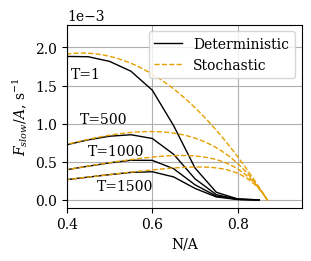

In [45]:
times = [1, 500, 1000, 1500]

f_slow_100 = {
    t: np.array([f_slow(
        sol_100[n], int(n), 100, t
    ) for n in sol_100.keys()]
               ) for t in times
}

#with open("f_slow_100_unsimplified.dat", "wb") as f:
#    pickle.dump(f_slow_100, f)

f, ax = plt.subplots(layout="constrained", figsize=(3, 2.5))

ax.set_prop_cycle(wong_cycle)

def fslow_det(N, A, T):
    """deterministic F_slow"""
    return (N-N*np.exp(-T*R+T*R*R*N/(A*K)))/T

for k in times:
    ax.plot(np.arange(5, 90, 5)/100, f_slow_100[k]/100, "-", color=wong_colors[0], linewidth=1)
    ax.plot(np.arange(0, 88)/100, fslow_det(np.arange(0, 88), 100, k)/100, "--", color=wong_colors[1], linewidth=1)

#ax2.plot(np.arange(6, 103, 6)/120, f_slow_120[1]/120, "-", label="T=1")
#ax2.plot(np.arange(3, 52, 3)/60, f_slow_60[1]/60, "-")
#ax2.plot(np.arange(0, 103)/120, fslow_det(np.arange(0, 103), 120, 1)/120, ":")

ax.grid(True)
ax.set_xlabel("N/A")
ax.set_ylabel("$F_{slow}/A$, s$^{-1}$")
ax.ticklabel_format(scilimits=(-2,5))
ax.set_xlim(left=0.4, right=0.95)
ax.set_ylim(top=0.0023)
lines = ax.get_lines()
ax.legend([lines[0], lines[1]], ["Deterministic", "Stochastic"])

ax.annotate("T=1", (0.41, 0.0016), xycoords="data", color="black")
ax.annotate("T=500", (0.43, 0.001), xycoords="data", color="black")
ax.annotate("T=1000", (0.45, 0.00058), xycoords="data", color="black")
ax.annotate("T=1500", (0.47, 0.00012), xycoords="data", color="black")

plt.savefig("fslow_kolmogorov.eps")
plt.savefig("fslow_kolmogorov.pdf")